In [ ]:
from scipy.stats import entropy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as colors

In [2]:
jades_data = pd.read_csv("data/jades_dr5_photometric_catalog_subset.csv").drop("Unnamed: 0", axis="columns")

In [3]:
jades_data

,F090W_KRON,F115W_KRON,F150W_KRON,F182M_KRON,F200W_KRON,F277W_KRON,F335M_KRON,F356W_KRON,F410M_KRON,F435W_KRON,...,F814W_KRON,F850LP_KRON,F125W_KRON,F140W_KRON,F160W_KRON,Q,R_KRON,unscaled_F444W_KRON,ID,photoz
0,0.386780,0.300087,0.633389,1.255446,0.623497,0.876420,0.909183,0.886891,1.136959,0.299658,...,0.728978,0.487159,0.888711,-0.537893,0.693334,0.390726,0.745056,116.064542,490,2.80
1,1.760779,2.398820,1.858198,1.308508,1.686628,1.652174,1.775756,1.824354,0.883753,1.589711,...,1.974697,2.307263,2.268095,0.739194,1.037109,0.915636,0.326000,25.601965,519,0.76
2,-0.869462,0.835223,0.112352,1.001784,0.545806,1.268684,1.460337,1.533824,0.732482,-0.230372,...,0.287732,0.086536,-0.079786,1.770051,1.758321,0.954687,0.509296,30.149901,522,3.49
3,1.173474,0.947350,1.528584,1.542125,1.162309,1.234815,1.141565,1.110963,1.376555,1.168281,...,0.547270,0.725842,1.058812,0.827280,2.331888,0.544861,0.420613,89.744492,549,2.42
4,1.688582,1.449304,1.279279,2.667931,1.834312,1.253783,1.194935,1.174235,1.060439,0.431678,...,1.587199,4.443156,2.505961,1.790643,4.172483,0.860860,0.421539,28.120277,550,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89725,-0.090871,0.080197,0.138278,0.184751,0.043777,0.056973,0.094905,0.109284,0.557477,-0.447143,...,-0.025884,0.722157,0.044524,0.266411,0.031988,0.743172,0.244562,26.270901,3301718,8.61
89726,0.454743,0.371896,-0.101835,-0.975059,0.115758,0.154993,0.673163,0.116752,0.328982,-0.699361,...,0.156044,-0.727166,0.048787,1.411943,0.003833,0.560676,0.395464,41.189591,3301754,4.99
89727,-0.695332,-0.328651,-0.470085,-0.029591,0.133646,0.299675,-0.168792,-0.478896,-0.248164,-0.014939,...,0.065822,-0.073610,-0.091850,0.616456,0.829263,0.896412,0.422729,33.786540,3301987,4.22
89728,0.477811,0.263739,-0.168404,0.547131,0.541751,-0.017597,-0.128883,0.163685,0.952204,1.251010,...,-0.195149,0.323955,0.737724,-0.032473,0.553756,0.730629,0.267007,20.080720,3302027,17.30


In [67]:
F277W_KRON = jades_data["F277W_KRON"].values
F444W_KRON = jades_data["unscaled_F444W_KRON"].values

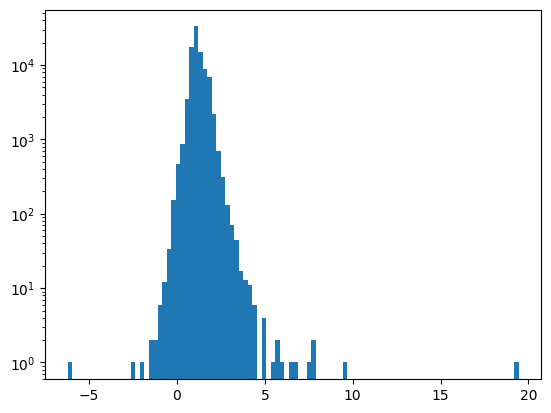

In [6]:
plt.hist(F277W_KRON, bins=100)
plt.yscale("log")
plt.show()

In [15]:
np.mean(F277W_KRON, keepdims=True)

array([1.20626993])

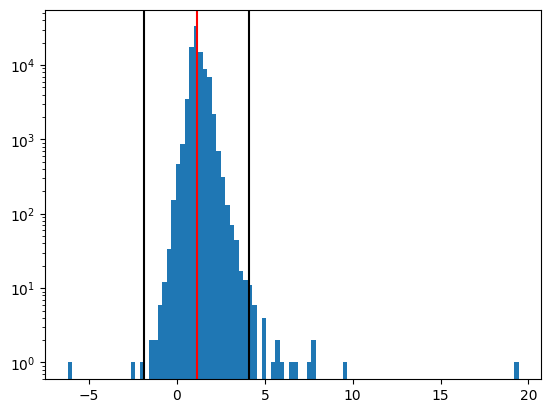

In [19]:
median = np.median(F277W_KRON)
stddev = np.std(F277W_KRON, mean=median) # this is cursed but is so that we can center the stddev calc at the median

lower_bound = median - 7*stddev
upper_bound = median + 7*stddev

plt.hist(F277W_KRON, bins=100)
plt.axvline(median, color="red")
plt.axvline(lower_bound, color="black")
plt.axvline(upper_bound, color="black")
plt.yscale("log")
plt.show()

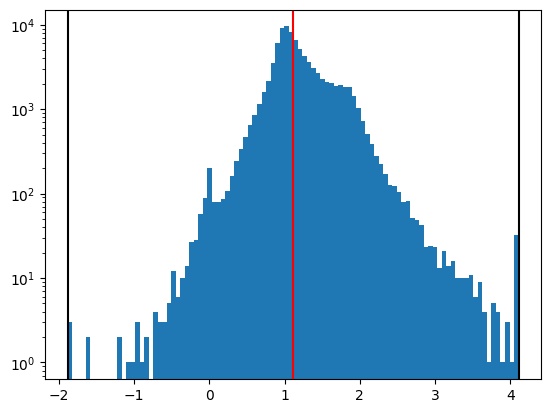

In [ ]:
upper_outliers =  F277W_KRON > upper_bound
lower_outliers =  F277W_KRON < lower_bound

F277W_KRON_modified = np.copy(F277W_KRON)
F277W_KRON_modified[upper_outliers] = upper_bound
F277W_KRON_modified[lower_outliers] = lower_bound

plt.hist(F277W_KRON_modified, bins=100)
plt.axvline(median, color="red")
plt.axvline(lower_bound, color="black")
plt.axvline(upper_bound, color="black")
plt.yscale("log")
plt.show()


# Testing for outliers

# Testing for models

Models that only work with positive data: Log (base 10 or e)

Models that work for all data: Asinh, Linear, SymmetricalLog (base 10 or e)

Since SymmetricalLog will work the same as Log on data > 0, we could be tempted to only use SymmetricalLog, but Log should still be an option because it doesn't require choosing a linear interval around zero.

Also: it seems like we should aim for our tool to return a norm from matplotlib.colors.

In [26]:
# these functions return a function that can be operated on data

def no_norm_operator(data):
    return colors.NoNorm(vmin=np.min(data), vmax=np.max(data))

def asinh_norm_operator(data, linear_width=1):
    return colors.AsinhNorm(vmin=np.min(data), vmax=np.max(data), linear_width=linear_width)

def log_norm_operator(data):
    return colors.LogNorm(vmin=np.min(data), vmax=np.max(data))

def symlog_norm_operator(data, linthresh=0.1):
    return colors.SymLogNorm(vmin=np.min(data), vmax=np.max(data), linthresh=linthresh)

In [97]:
def get_scatterscale(data):
    all_scalings = [no_norm_operator, asinh_norm_operator, symlog_norm_operator, log_norm_operator]
    all_scaling_names = ["No normalization", "Asinh (linear_width=1)", "SymLog (linthresh=0.1)", "Log"]
    if not np.all(data > 0):
        all_scalings = all_scalings[:-1] # get rid of log scaling option for data that has values <= 0

    entropies = []
    for i, get_scaling_operator in enumerate(all_scalings):
        scaling_operator = get_scaling_operator(data)
        scaled_data = scaling_operator(data)

        if all_scaling_names[i] == "No normalization":
            # scale to a range of 0 to 1
            scaled_data_min = np.min(scaled_data)
            scaled_data_max = np.max(scaled_data)
            reranged_scaled_data = (scaled_data - scaled_data_min) / (scaled_data_max - scaled_data_min)
            entropies.append(entropy(reranged_scaled_data))
        else:
            entropies.append(entropy(scaled_data))

    loc_max_entropy = np.argmax(entropies)
    get_best_scaling_operator = all_scalings[loc_max_entropy]
    print(f"Best scaling: {all_scaling_names[loc_max_entropy]}")
    return get_best_scaling_operator(data)

Best scaling: SymLog (linthresh=0.1)


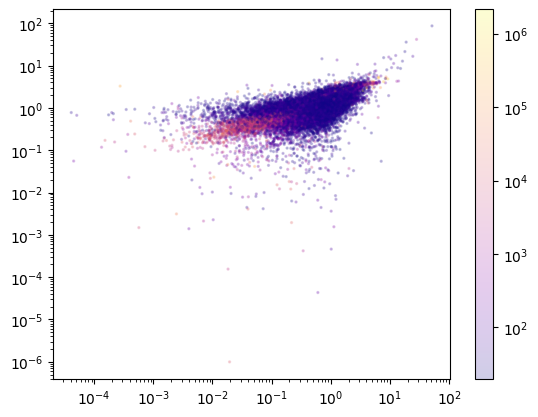

In [102]:
F444W_KRON_norm = get_scatterscale(F444W_KRON)
plt.scatter(jades_data["F090W_KRON"], jades_data["F200W_KRON"], c=F444W_KRON, norm=F444W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

Best scaling: No normalization


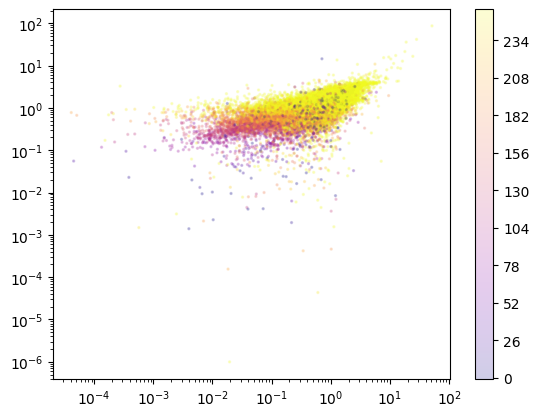

In [100]:
F277W_KRON_norm = get_scatterscale(F277W_KRON)
plt.scatter(jades_data["F090W_KRON"], jades_data["F200W_KRON"], c=F277W_KRON, norm=F277W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

In [104]:
from choose_scaler import get_scatterscale as scatterscale_test

Best scaling: No normalization


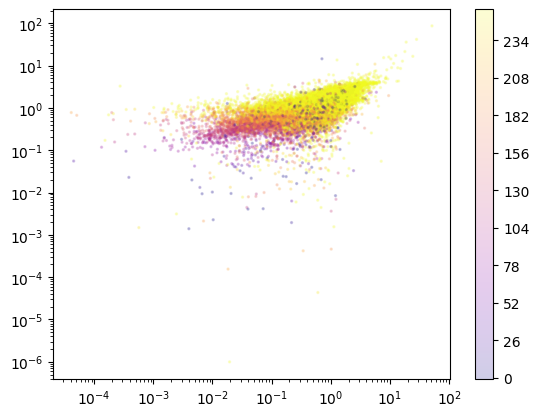

In [105]:
F277W_KRON_norm = scatterscale_test(F277W_KRON)
plt.scatter(jades_data["F090W_KRON"], jades_data["F200W_KRON"], c=F277W_KRON, norm=F277W_KRON_norm, cmap="plasma", alpha=0.2, s=2)
plt.xscale("log")
plt.yscale("log")
plt.colorbar()
plt.show()

In [107]:
type(F277W_KRON_norm)

matplotlib.colors.NoNorm